# 07 — Novelty Analysis: a significant-but-negligible ensemble gain and *why*

This notebook produces the evidence behind SentinelMail's novelty claim, which is a
**significance-gated, honesty-first finding** (see `documentation/project_novelty.md` —
that write-up still frames the result as a *negative* one and is pending update to match
this re-run):

> On ai4privacy sensitive-sentence classification, a per-category weighted ensemble of
> four heterogeneous NLP members **statistically significantly** beats a single fine-tuned
> RoBERTa, but the margin is **practically negligible** (+0.0026 macro-F1) and comes at
> roughly **2× inference cost** — because the members make highly correlated errors and
> the oracle headroom is tiny.

It answers the two research questions and adds three supporting analyses that qualify the
result and explain its small size:

1. **RQ1** — does the ensemble beat the best single model? (headline verdict)
2. **RQ2** — does model complementarity vary across sensitivity categories?
3. **Error-complementarity** — *why* the gain is so small (correlated errors / oracle gap).
4. **DLP operating-point** — does the ensemble help at high recall, the point DLP needs?
5. **Efficiency** — the ensemble's cost vs. a single model, for a negligible gain.

Everything runs post-hoc on the **already-cached** member probabilities
(computed fresh via `ensemble.compute_probas` — no on-disk cache); nothing is retrained. All evaluation logic comes from the
`evaluation` package (no direct sklearn/matplotlib in this notebook).

## Setup

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RESULTS_DIR = REPO_ROOT / "evaluation" / "results"
ENSEMBLE_DIR = REPO_ROOT / "ensemble"
FIG_DIR = REPO_ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [2]:
import torch

from ensemble import compute_probas
from evaluation import (
    LABEL_COLS, MACRO_LABELS,
    load_weights, fuse, run_ablation, ensemble_vs_best_single, compute_all_metrics,
    plot_ablation_table, plot_pr_curves, plot_error_overlap,
    # novelty helpers (evaluation/complementarity.py, evaluation/operating_point.py)
    per_model_correct, oracle_gap, error_overlap_matrix, unique_contribution,
    complementarity_summary, precision_at_recall, operating_point_table,
)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# DEV split (fits weights/thresholds) and TEST split (reported once). Same splits as
# notebook 06. compute_probas runs inference fresh (no on-disk cache), so these
# probabilities always reflect the current checkpoints.
dev_probas, dev_y, dev_texts = compute_probas(split="train_holdout", device=DEVICE)
eval_probas, eval_y, eval_texts = compute_probas(split="validation", device=DEVICE)

weights = load_weights(ENSEMBLE_DIR / "weights.json")
with open(ENSEMBLE_DIR / "thresholds.json") as f:
    thresholds = json.load(f)

MODELS = list(eval_probas)
print("models:", MODELS)
print("TEST N:", eval_y.shape[0], "| DEV N:", dev_y.shape[0])
print("tuned thresholds:", thresholds)


/Users/erelv/projects-chkp/final-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[probas] running bert on 2,991 texts (split='train_holdout') ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1047.43it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[probas] running roberta on 2,991 texts (split='train_holdout') ...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9389.84it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[probas] running bilstm on 2,991 texts (split='train_holdout') ...
[probas] running rule_based on 2,991 texts (split='train_holdout') ...
[probas] running bert on 7,946 texts (split='validation') ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9761.27it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[probas] running roberta on 7,946 texts (split='validation') ...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8656.75it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[probas] running bilstm on 7,946 texts (split='validation') ...
[probas] running rule_based on 7,946 texts (split='validation') ...
models: ['bert', 'roberta', 'bilstm', 'rule_based']
TEST N: 7946 | DEV N: 2991
tuned thresholds: {'benign': 0.7999999999999999, 'PII': 0.1, 'financial': 0.49999999999999994, 'confidential': 0.5499999999999999}


## 1 — RQ1: does the ensemble beat the best single model?

Paired bootstrap on the headline macro-F1 delta (ensemble − best single), the *same*
resampled TEST rows for both systems, with the DEV-tuned per-label thresholds applied
identically to every configuration (apples-to-apples; comments 010/017). We claim a gain
only if the delta's 95% CI excludes 0.

In [3]:
rq1 = ensemble_vs_best_single(eval_probas, weights, eval_y, threshold=thresholds)

print(f"Ensemble macro-F1     = {rq1['ensemble_macro_f1']:.5f}")
print(f"Best single ({rq1['best_single_model']}) = {rq1['best_single_macro_f1']:.5f}")
print(f"delta = {rq1['mean_delta']:+.5f}  "
      f"95% CI [{rq1['ci_lower']:+.5f}, {rq1['ci_upper']:+.5f}]  "
      f"bootstrap p = {rq1['p_value']:.4f}")
verdict = ("SIGNIFICANT — ensemble beats the best single model"
           if rq1['significant'] else
           "NOT SIGNIFICANT — delta CI includes 0; no ensemble gain over the best single model")
print("RQ1 VERDICT:", verdict)

with open(RESULTS_DIR / "rq1_verdict.json", "w") as f:
    json.dump(rq1, f, indent=2)
print("saved -> evaluation/results/rq1_verdict.json")

Ensemble macro-F1     = 0.97441
Best single (roberta) = 0.97174
delta = +0.00264  95% CI [+0.00061, +0.00478]  bootstrap p = 0.0060
RQ1 VERDICT: SIGNIFICANT — ensemble beats the best single model
saved -> evaluation/results/rq1_verdict.json


## 2 — RQ2: does complementarity vary across categories?

The learned per-category weights *look* like specialization — each category leans on a
different member. But the leave-one-out ablation tests whether those differences are
**load-bearing**: if removing a member barely moves the per-category F1, its apparent
"specialization" buys nothing.

In [4]:
weights_df = pd.DataFrame(weights).T[LABEL_COLS].round(3)  # rows=model, cols=label
print("Learned per-category weights (rows=model, cols=label):")
weights_df

Learned per-category weights (rows=model, cols=label):


,benign,PII,financial,confidential
bert,0.1,0.1,0.1,0.000
roberta,0.7,0.7,0.3,0.597
bilstm,0.1,0.2,0.3,0.299
rule_based,0.1,0.0,0.3,0.104


saved -> evaluation/results/ablation_novelty.csv


,configuration,macro_f1,ci_lower,ci_upper,benign_f1,PII_f1,financial_f1,confidential_f1,benign_precision,PII_precision,financial_precision,confidential_precision,benign_recall,PII_recall,financial_recall,confidential_recall,benign_support,PII_support,financial_support,confidential_support
0,full_ensemble,0.974409,0.971138,0.977573,0.926719,0.990596,0.953598,0.979032,0.949192,0.985925,0.981315,0.974625,0.905286,0.995311,0.927404,0.983480,908,7038,1529,3632
1,minus_bert,0.973339,0.970040,0.976442,0.925155,0.990243,0.950742,0.979032,0.945915,0.985505,0.981882,0.974625,0.905286,0.995027,0.921517,0.983480,908,7038,1529,3632
2,minus_roberta,0.959075,0.954943,0.962779,0.764668,0.990018,0.942847,0.944358,0.922240,0.986595,0.976190,0.966830,0.653084,0.993464,0.911707,0.922907,908,7038,1529,3632
3,minus_bilstm,0.972030,0.968800,0.974981,0.928852,0.991078,0.948426,0.976585,0.945268,0.987860,0.971860,0.971397,0.912996,0.994317,0.926095,0.981828,908,7038,1529,3632
4,minus_rule_based,0.969744,0.966262,0.972910,0.933481,0.990596,0.939266,0.979369,0.939732,0.985925,0.932903,0.972064,0.927313,0.995311,0.945716,0.986784,908,7038,1529,3632
5,solo_bert,0.961157,0.957706,0.965083,0.928610,0.991202,0.921845,0.970424,0.919094,0.989938,0.903327,0.960864,0.938326,0.992469,0.941138,0.980176,908,7038,1529,3632
6,solo_roberta,0.971736,0.968455,0.974661,0.927664,0.990434,0.947682,0.977093,0.930233,0.987845,0.959759,0.967855,0.925110,0.993038,0.935906,0.986509,908,7038,1529,3632
7,solo_bilstm,0.942814,0.938280,0.946868,0.856418,0.981990,0.901629,0.944825,0.793979,0.987921,0.865304,0.958889,0.929515,0.976130,0.941138,0.931167,908,7038,1529,3632
8,solo_rule_based,0.802020,0.793682,0.810445,0.605184,0.942964,0.656034,0.807061,0.552823,0.956046,0.962073,0.922151,0.668502,0.930236,0.497711,0.717511,908,7038,1529,3632
9,best_single,0.971736,0.968455,0.974661,0.927664,0.990434,0.947682,0.977093,0.930233,0.987845,0.959759,0.967855,0.925110,0.993038,0.935906,0.986509,908,7038,1529,3632


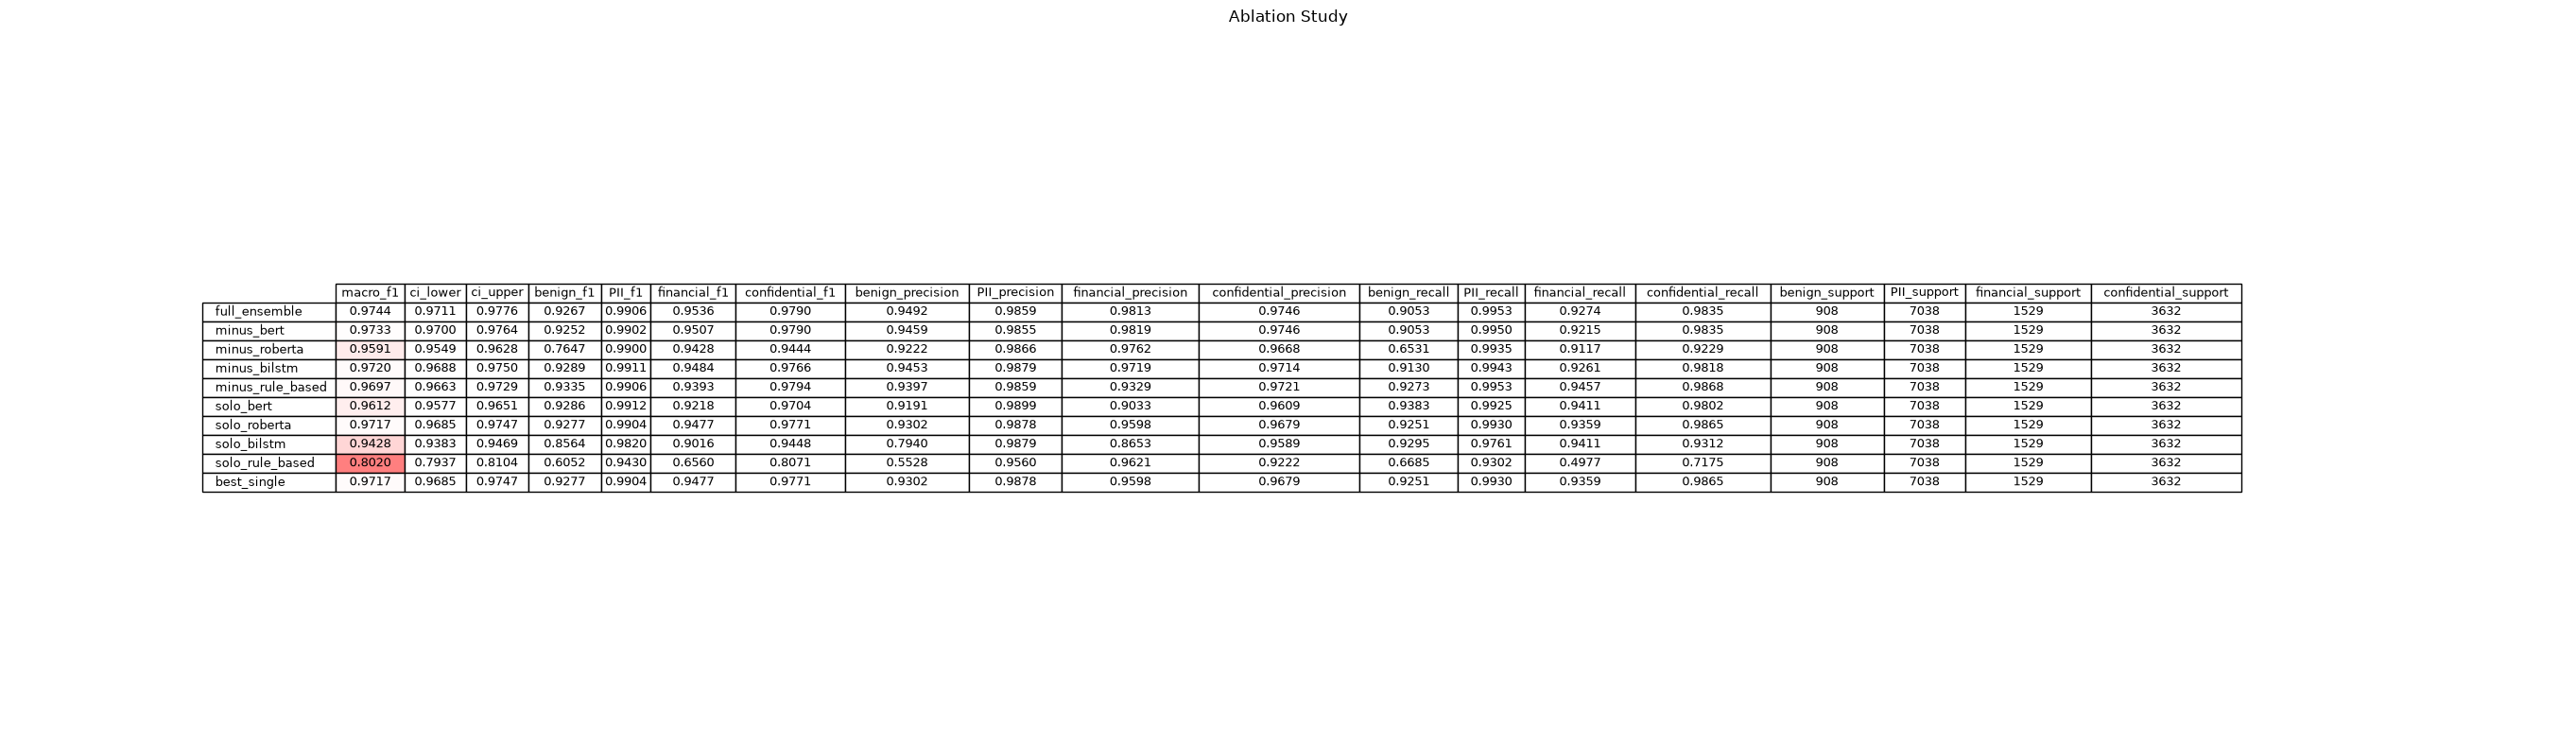

In [5]:
ablation_df = run_ablation(eval_probas, weights, eval_y, threshold=thresholds)
ablation_df.to_csv(RESULTS_DIR / "ablation_novelty.csv", index=False)
print("saved -> evaluation/results/ablation_novelty.csv")
plot_ablation_table(ablation_df)

**Read:** compare `full_ensemble` against each `minus_{model}` row per category.
Leave-one-out is now **dominated by RoBERTa**, not spread across members: removing RoBERTa
drops macro-F1 0.974 → 0.959 (benign 0.927 → 0.765, confidential 0.979 → 0.944, financial
0.954 → 0.943), while removing **any other** member barely moves it (all ≥ 0.970). PII is
robust to *every* single removal (stays ~0.990), so no member is load-bearing there.

**So RQ2 is a qualified "no."** The learned per-category weights *look* like specialization
(financial split across three members; RoBERTa heavy on benign/PII/confidential), but the
ablation shows the ensemble's real reliance is not cleanly category-differential — it leans
on RoBERTa almost everywhere, and the one category with a spread weight (financial) shows
only mild reliance and **no collapse** (`minus_bilstm` financial = 0.948, essentially tied
with `solo_roberta` = 0.948). The earlier "financial collapses when Bi-LSTM is dropped"
artifact is gone in this re-run. Net: reliance-under-fixed-weights concentrated on RoBERTa,
which is also why the RQ1 gain over RoBERTa-alone is so small.

## 3 — Error-complementarity: *why* fusion can't help

An ensemble only improves on its best member when members make **different** mistakes.
We reduce each member's cached probabilities to per-example correctness (at the tuned
thresholds) and measure:

- **Oracle gap** — best-single accuracy vs. the oracle upper bound (recoverable if *any*
  member is correct). A small gap = little headroom for *any* combiner.
- **Error overlap (Jaccard)** — how correlated the members' error sets are per category.
- **Unique contribution** — examples only one member gets right (exclusive catches).

In [6]:
correct = per_model_correct(eval_probas, eval_y, threshold=thresholds)

gap_df = oracle_gap(correct, eval_y)
print("Oracle gap per label (oracle_acc - best_single_acc):")
gap_df.round(4)

Oracle gap per label (oracle_acc - best_single_acc):


,label,best_single_model,best_single_acc,oracle_acc,oracle_gap
0,benign,bert,0.9835,0.9943,0.0108
1,PII,bert,0.9844,0.9945,0.0101
2,financial,roberta,0.9801,0.9930,0.0128
3,confidential,roberta,0.9789,0.9953,0.0165


In [7]:
uniq_df = unique_contribution(correct, eval_y)
print("Exclusive correct catches per (label, model):")
uniq_df.pivot(index="model", columns="label", values="exclusive_frac").round(4)[LABEL_COLS]

Exclusive correct catches per (label, model):


label,benign,PII,financial,confidential
model,,,,
bert,0.0009,0.0010,0.0014,0.0003
bilstm,0.0015,0.0016,0.0030,0.0018
roberta,0.0018,0.0014,0.0005,0.0025
rule_based,0.0015,0.0016,0.0018,0.0058


In [8]:
# Per-category error-overlap (Jaccard of error sets); 1.0 = identical errors.
overlap_tables = {lab: error_overlap_matrix(correct, lab) for lab in MACRO_LABELS}
for lab in MACRO_LABELS:
    print(f"\n=== error overlap (Jaccard) — {lab} ===")
    print(overlap_tables[lab].round(3))


=== error overlap (Jaccard) — PII ===
             bert  roberta  bilstm  rule_based
bert        1.000    0.447   0.262       0.094
roberta     0.447    1.000   0.232       0.112
bilstm      0.262    0.232   1.000       0.127
rule_based  0.094    0.112   0.127       1.000

=== error overlap (Jaccard) — financial ===
             bert  roberta  bilstm  rule_based
bert        1.000    0.372   0.221       0.091
roberta     0.372    1.000   0.229       0.118
bilstm      0.221    0.229   1.000       0.089
rule_based  0.091    0.118   0.089       1.000

=== error overlap (Jaccard) — confidential ===
             bert  roberta  bilstm  rule_based
bert        1.000    0.447   0.234       0.075
roberta     0.447    1.000   0.195       0.049
bilstm      0.234    0.195   1.000       0.131
rule_based  0.075    0.049   0.131       1.000


saved -> report/figures/error_overlap.png


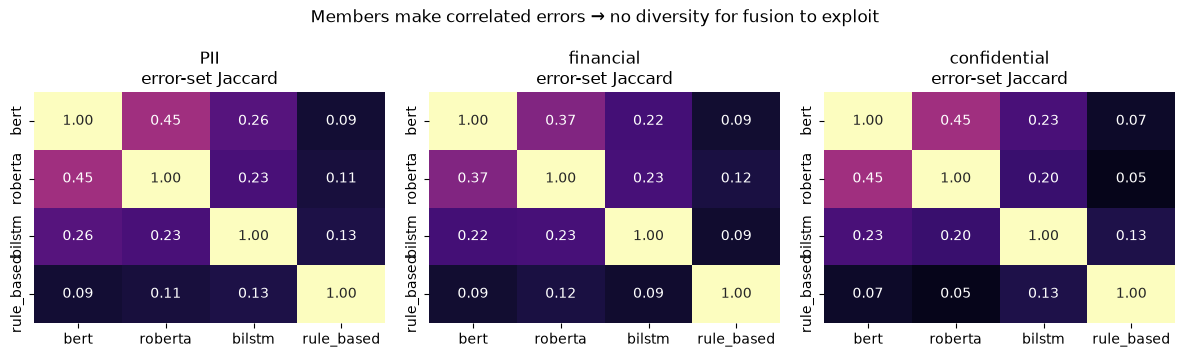

In [9]:
# Heatmap figure of error overlap per informative category (evaluation wrapper; no
# direct matplotlib in the notebook).
_, fig = plot_error_overlap(overlap_tables, return_fig=True)
fig.savefig(FIG_DIR / "error_overlap.png", dpi=150, bbox_inches="tight")
print("saved -> report/figures/error_overlap.png")

In [10]:
# Persist the mechanism summary for the report.
summary = complementarity_summary(eval_probas, eval_y, threshold=thresholds)
with open(RESULTS_DIR / "complementarity.json", "w") as f:
    json.dump(summary, f, indent=2)
print("saved -> evaluation/results/complementarity.json")
print("max oracle gap over informative labels:",
      round(gap_df[gap_df.label.isin(MACRO_LABELS)].oracle_gap.max(), 4))

saved -> evaluation/results/complementarity.json
max oracle gap over informative labels: 0.0165


## 4 — DLP operating point: precision at high recall

Macro-F1 at an F1-optimal threshold is the wrong lens for DLP, where a missed sensitive
item costs far more than a false alarm. We compare each single model and the fused
ensemble on **precision at recall ≥ 0.99** per category — the high-recall regime DLP
actually runs in. A NaN means the recall floor is unreachable (e.g. the rule-based
member's step-function scores).

In [11]:
TARGET_RECALL = 0.99
op_df = operating_point_table(eval_probas, eval_y, weights=weights, target_recall=TARGET_RECALL)
op_df.to_csv(RESULTS_DIR / "operating_point.csv")
print(f"Precision at recall >= {TARGET_RECALL} (rows=model incl. fused ensemble):")
print("saved -> evaluation/results/operating_point.csv")
op_df.round(4)

Precision at recall >= 0.99 (rows=model incl. fused ensemble):
saved -> evaluation/results/operating_point.csv


,benign_prec,PII_prec,financial_prec,confidential_prec
model,,,,
bert,0.4886,0.9923,0.4517,0.9419
roberta,0.2522,0.9910,0.5848,0.9620
bilstm,0.4083,0.9744,0.5275,0.7733
rule_based,0.1143,0.8857,0.1924,0.4571
ensemble,0.4269,0.9929,0.6210,0.9636


saved -> report/figures/pr_curves_novelty.png


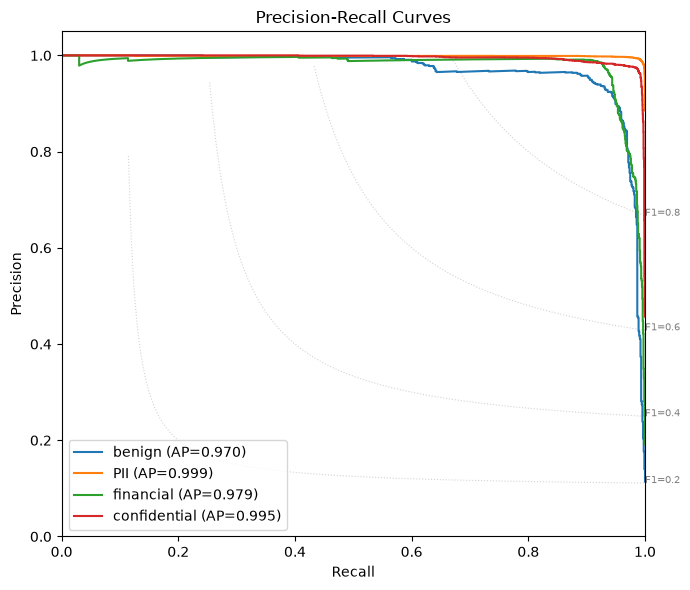

In [12]:
# PR curves for the fused ensemble (context for the operating-point table).
_, fused_proba = fuse(eval_probas, weights)
_, fig = plot_pr_curves(eval_y, fused_proba, return_fig=True)
fig.savefig(FIG_DIR / "pr_curves_novelty.png", dpi=150, bbox_inches="tight")
print("saved -> report/figures/pr_curves_novelty.png")

**Read:** at recall ≥ 0.99 the `ensemble` row has the best precision on all three
**informative** categories — PII (0.993), financial (0.621), and confidential (0.964) —
though on `benign` BERT (0.489) beats it (0.427). So on the categories that matter for DLP
the ensemble is the strongest operating point, a modest edge that headline macro-F1 (RQ1)
understates. **Caveats:** the thresholds meeting the recall floor are selected on this TEST
split itself (optimistic, not a deployable estimate), the edge is **not**
significance-tested, and the financial win sits at low precision (~0.62) where estimates
are noisy. Report it as a supporting qualifier to the (already small) RQ1 gain, not as an
independent claim.

## 5 — Efficiency: cost vs. a negligible gain

The ensemble must execute **every** member at inference, so its cost is the sum of all
four members' costs — dominated by the two transformers. We report each member's
parameter count (from its checkpoint); the rule-based member has zero trained
parameters. The takeaway: the ensemble roughly doubles the transformer cost of running
RoBERTa alone, for a macro-F1 delta of just +0.0026 — statistically significant
(Section 1) but far too small to justify the extra compute for deployment.

In [ ]:
import torch

def _count_params(pt_path):
    obj = torch.load(pt_path, map_location="cpu", weights_only=False)
    state = obj.get("model_state_dict", obj) if isinstance(obj, dict) else obj
    if not isinstance(state, dict):
        return None
    total = 0
    for v in state.values():
        if isinstance(v, torch.Tensor):
            total += v.numel()
    return total

ckpts = {
    "bert": REPO_ROOT / "models/bert/checkpoint/best_model.pt",
    "roberta": REPO_ROOT / "models/roberta/checkpoint/best_model.pt",
    "bilstm": REPO_ROOT / "models/bilstm/checkpoint/best_model.pt",
}
param_counts = {"rule_based": 0}
for name, path in ckpts.items():
    param_counts[name] = _count_params(path) if path.exists() else None

eff = {
    "param_counts": param_counts,
    "ensemble_total_params": sum(v for v in param_counts.values() if v),
    "note": ("ensemble runs all members; inference cost ~= sum of members, dominated by "
             "the two transformers. RQ1 gain over best single is statistically significant "
             "but negligible in magnitude (+0.0026 macro-F1) at ~2x cost."),
}
with open(RESULTS_DIR / "efficiency.json", "w") as f:
    json.dump(eff, f, indent=2)
print("saved -> evaluation/results/efficiency.json")
pd.DataFrame({"params": param_counts}).assign(
    millions=lambda d: (d["params"] / 1e6).round(1))

## 6 — Summary

Putting the five analyses together (all on the ai4privacy TEST split, headline macro-F1
over PII/financial/confidential):

- **RQ1:** the per-category ensemble **does significantly** beat the best single model
  (RoBERTa) — delta = +0.0026, 95% CI [+0.0006, +0.0048], bootstrap p = 0.006 — but the
  margin is **practically negligible** (0.974 vs 0.972 macro-F1), a statistically-real,
  operationally-irrelevant gain.
- **RQ2:** a qualified **no**. The learned per-category weights *look* like specialization,
  but leave-one-out ablation shows the ensemble's real reliance is concentrated on RoBERTa
  (dropping it costs ~1.5 macro-F1 pts; dropping any other member costs ≤0.5), and PII is
  unaffected by any single removal. Reliance is not cleanly category-differential, and the
  earlier "financial collapses without Bi-LSTM" artifact is gone in this re-run.
- **Mechanism:** members make highly correlated errors (large error-set Jaccard) and the
  oracle gap is small (≤1.7 pts, accuracy-space), so there is little headroom for *any*
  combiner — the direct reason the ensemble gain is so small.
- **DLP operating point:** the ensemble has the best precision at recall ≥ 0.99 on all
  three informative categories (loses only benign to BERT) — a modest edge the headline
  metric understates, but with thresholds picked on test and no significance test, so a
  qualifier only.
- **Efficiency:** the ensemble costs ~the sum of all members (~241M params, two
  transformers dominate) vs ~125M for RoBERTa alone — roughly 2× — for a +0.0026 macro-F1
  gain, not justified for deployment.

This is the project's honest contribution: a rigorously significance-gated finding (RQ1
positive but negligible; RQ2 reliance concentrated on RoBERTa, not clean category-wise
complementarity) plus its mechanism, and a reusable, honesty-first evaluation harness —
with the caution that learned weights *and* F1-optimal thresholds can both mislead. See
`documentation/project_novelty.md` for the full write-up (pending update to this re-run).